# **SECTION #01**

The dataset used in this project contains comprehensive records of earthquake events that occured globally.

It includes information about seismic activities, including date, time, location, magnitude and other features.This dataset is from the past 30 days.

It was obtained from the USGS (United States Geological Survey) Earthquake catelog, a tursted and widely-used source for seismic data

# **SECTION #02**

In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv('earthquake.csv')

In [3]:
df.shape

(1998, 22)

It means the dataset has 1,998 rows and 22 columns

In [4]:
df.dtypes

,0
time,object
latitude,float64
longitude,float64
depth,float64
mag,float64
magType,object
nst,int64
gap,int64
dmin,float64
rms,float64


11 object - pandas instead of string says object type

10 float  - decimal numbers

2 integers- simple integers could be positive or negatve

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1998 entries, 0 to 1997
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   time             1998 non-null   object 
 1   latitude         1998 non-null   float64
 2   longitude        1998 non-null   float64
 3   depth            1998 non-null   float64
 4   mag              1998 non-null   float64
 5   magType          1998 non-null   object 
 6   nst              1998 non-null   int64  
 7   gap              1998 non-null   int64  
 8   dmin             1998 non-null   float64
 9   rms              1998 non-null   float64
 10  net              1998 non-null   object 
 11  id               1998 non-null   object 
 12  updated          1998 non-null   object 
 13  place            1998 non-null   object 
 14  type             1998 non-null   object 
 15  horizontalError  1980 non-null   float64
 16  depthError       1997 non-null   float64
 17  magError      

tells information abotu the dataset the null values each feature has and the data type

In [6]:
df.describe()

,latitude,longitude,depth,mag,nst,gap,dmin,rms,horizontalError,depthError,magError,magNst
count,1998.000000,1998.000000,1998.000000,1998.000000,1998.000000,1998.000000,1998.000000,1998.000000,1980.000000,1997.000000,1985.000000,1994.000000
mean,25.964352,-17.530033,56.012849,3.820919,45.910410,136.081582,2.301723,0.662149,8.083124,4.944273,0.121465,44.466399
std,28.614080,134.255396,96.139526,0.933394,38.410331,75.053317,3.804523,0.305262,6.420470,4.979418,0.101853,58.409056
min,-61.768200,-179.999200,-2.750000,2.500000,3.000000,11.000000,0.000000,0.030000,0.000000,0.000000,0.000000,1.000000
25%,5.233650,-151.996500,10.000000,2.900000,20.000000,75.000000,0.500000,0.472500,3.775000,1.888000,0.074000,13.000000
50%,32.568250,-66.856900,21.850000,4.100000,33.000000,125.000000,1.268000,0.670000,8.000000,3.014300,0.100000,23.500000
75%,51.791425,125.377150,62.288500,4.500000,57.750000,195.000000,2.339000,0.870000,10.962500,7.101000,0.152000,54.000000
max,83.852100,179.963000,616.793000,7.800000,276.000000,359.000000,39.329000,1.930000,82.700000,41.620000,3.400000,734.000000


this function describes the numerical columns

their total count

mean - standard deviation

min and max values

and the IQR values Q1,Q2,Q3

In [7]:
df.isnull().sum()

,0
time,0
latitude,0
longitude,0
depth,0
mag,0
magType,0
nst,0
gap,0
dmin,0
rms,0


checks the null values and sums them for each respective columns separately

like horizontal error has 18 null values

and MagNst has 4 null values

In [10]:
df['locationSource'].value_counts()

,count
locationSource,
us,1282
ak,399
pr,132
nc,57
hv,39
tx,30
ci,26
nn,16
uu,7


shows all the categories within a feature like LoationSource has 13 values in total, like any value in this feature would be from these 13 categories

In [11]:
df.duplicated().sum()

np.int64(0)

it shows total count of dupliacted values

# **SECTION #03**

In [12]:
df.head(10)

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,2026-07-01T08:00:50.534Z,-20.536300,-67.923200,171.032000,4.50,mb,33,65,1.22000,1.18,...,2026-07-01T08:49:52.040Z,"83 km NNE of Ollagüe, Chile",earthquake,7.06,10.283000,0.156000,12.0,reviewed,us,us
1,2026-07-01T06:39:49.260Z,19.171167,-155.438171,40.970001,2.72,md,24,168,0.07636,0.34,...,2026-07-01T08:48:07.235Z,"5 km SE of Pāhala, Hawaii",earthquake,1.25,1.800000,0.135766,13.0,automatic,hv,hv
2,2026-07-01T06:23:39.283Z,-22.797200,170.710200,45.455000,4.90,mb,29,137,3.01900,1.17,...,2026-07-01T06:49:17.040Z,southeast of the Loyalty Islands,earthquake,8.28,6.004000,0.114000,24.0,reviewed,us,us
3,2026-07-01T05:56:41.300Z,32.352667,-115.247500,15.620000,2.65,ml,37,52,0.08251,0.32,...,2026-07-01T06:07:17.020Z,"5 km W of Delta, B.C., MX",earthquake,0.37,0.730000,0.201009,26.0,automatic,ci,ci
4,2026-07-01T05:06:40.700Z,19.200167,-155.494500,31.700000,3.38,ml,55,141,0.04814,0.13,...,2026-07-01T07:24:40.324Z,"1 km W of Pāhala, Hawaii",earthquake,0.40,0.480000,0.186027,43.0,reviewed,hv,hv
5,2026-07-01T04:47:58.064Z,31.612000,-104.487000,7.108700,2.60,ml,8,269,0.10000,0.10,...,2026-07-01T05:00:37.471Z,"63 km S of Whites City, New Mexico",earthquake,0.00,14.273012,3.400000,2.0,automatic,tx,tx
6,2026-07-01T04:41:03.674Z,45.817200,-80.754000,9.702000,2.60,mb_lg,11,115,1.02200,0.74,...,2026-07-01T04:51:18.040Z,"75 km SSE of Lively, Canada",earthquake,4.49,7.845000,0.082000,39.0,reviewed,us,us
7,2026-07-01T04:34:13.180Z,-30.683100,-64.382000,10.000000,4.40,mb,37,65,1.62000,0.70,...,2026-07-01T08:54:08.803Z,"24 km NE of Capilla del Monte, Argentina",earthquake,7.46,1.897000,0.161000,11.0,reviewed,us,us
8,2026-07-01T04:07:45.859Z,71.127800,-6.936400,10.000000,4.20,mb,28,93,4.99400,1.31,...,2026-07-01T04:23:54.040Z,"68 km ENE of Olonkinbyen, Svalbard and Jan Mayen",earthquake,7.77,1.840000,0.128000,17.0,reviewed,us,us
9,2026-07-01T02:00:38.195Z,-8.855500,-74.831000,130.525000,5.00,mb,60,102,3.68800,0.74,...,2026-07-01T02:16:08.040Z,"16 km WNW of Tournavista, Peru",earthquake,9.41,8.009000,0.030000,352.0,reviewed,us,us


head(10) shows the top 10 values from the dataset

In [13]:
df.tail(5)

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
1993,2026-06-01T01:24:38.944Z,61.118400,-140.112400,5.000,2.60,ml,34,70,0.5260,1.17,...,2026-06-19T23:13:03.040Z,"154 km ESE of McCarthy, Alaska",earthquake,2.26,1.961,0.044000,68.0,reviewed,us,us
1994,2026-06-01T00:36:36.507Z,1.725700,126.589800,68.592,4.20,mb,14,152,9.5650,0.37,...,2026-06-25T03:19:10.040Z,"136 km NW of Ternate, Indonesia",earthquake,15.42,11.121,0.186000,9.0,reviewed,us,us
1995,2026-06-01T00:33:28.750Z,18.909333,-64.831833,34.170,3.39,md,23,236,0.5263,0.25,...,2026-06-01T02:48:31.040Z,"63 km N of Charlotte Amalie, U.S. Virgin Islands",earthquake,2.05,6.250,0.130318,15.0,reviewed,pr,pr
1996,2026-06-01T00:25:16.746Z,59.776000,-153.811000,151.300,2.60,ml,106,57,0.3000,0.80,...,2026-06-30T22:48:24.040Z,"16 km E of Pedro Bay, Alaska",earthquake,3.70,1.556,0.400000,78.0,reviewed,ak,ak
1997,2026-06-01T00:08:41.322Z,-57.802200,157.706500,10.000,4.90,mb,33,99,3.3830,0.91,...,2026-06-25T03:15:40.040Z,Macquarie Island region,earthquake,12.74,1.905,0.100000,31.0,reviewed,us,us


.tail(5) shows the trailing 5 values form the dataset

In [14]:
df.sample(15)

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
1277,2026-06-10T10:34:17.371Z,43.6289,135.6736,343.3130,5.7,mww,100,26,2.723,0.69,...,2026-06-11T11:00:26.031Z,"33 km ESE of Ol’ga, Russia",earthquake,8.27000,7.121000,0.058,29.0,reviewed,us,us
561,2026-06-20T23:19:10.368Z,52.0499,-174.4024,156.8020,2.9,ml,16,221,0.198,0.42,...,2026-06-23T01:54:16.040Z,"21 km SW of Atka, Alaska",earthquake,19.09000,6.899000,0.097,14.0,reviewed,us,us
1815,2026-06-03T22:00:03.150Z,-20.3180,-173.8442,10.0000,4.9,mb,51,126,18.464,0.55,...,2026-06-25T04:30:43.040Z,"77 km SE of Pangai, Tonga",earthquake,14.36000,1.850000,0.079,50.0,reviewed,us,us
1509,2026-06-08T02:56:15.627Z,5.0521,125.3116,35.0000,4.6,mb,33,136,2.022,1.01,...,2026-06-26T04:13:20.040Z,"42 km SSW of Sarangani, Philippines",earthquake,13.37000,1.631000,0.081,46.0,reviewed,us,us
1929,2026-06-01T23:53:54.554Z,-11.0972,-75.5269,114.5820,4.2,mb,25,108,1.563,0.91,...,2026-06-25T04:11:14.040Z,"18 km W of San Ramón, Peru",earthquake,8.63000,6.090000,0.141,14.0,reviewed,us,us
927,2026-06-15T13:03:41.869Z,-22.2206,-68.5518,125.8960,4.4,mb,21,46,0.767,0.65,...,2026-06-25T16:09:33.040Z,"46 km NE of Calama, Chile",earthquake,5.93000,6.097000,0.267,4.0,reviewed,us,us
103,2026-06-28T19:23:54.298Z,61.9740,-150.5280,26.8000,2.7,ml,105,31,0.500,1.10,...,2026-06-28T19:34:51.800Z,"36 km NW of Willow, Alaska",earthquake,1.70000,2.242600,0.100,76.0,automatic,ak,ak
906,2026-06-15T20:16:15.944Z,5.5743,125.2603,35.0000,4.9,mb,61,55,1.519,0.69,...,2026-06-26T15:23:55.040Z,"10 km W of Balangonan, Philippines",earthquake,9.50000,1.818000,0.057,96.0,reviewed,us,us
1917,2026-06-02T04:54:22.057Z,-6.5211,130.2206,165.2090,4.2,mb,11,122,4.109,0.60,...,2026-06-24T03:16:29.040Z,"297 km WSW of Tual, Indonesia",earthquake,8.19000,12.702000,0.215,6.0,reviewed,us,us
1661,2026-06-06T08:52:05.095Z,-10.3426,161.5317,80.9200,4.6,mb,40,81,1.801,0.59,...,2026-06-30T15:05:22.040Z,"44 km WNW of Kirakira, Solomon Islands",earthquake,5.21000,7.329000,0.076,51.0,reviewed,us,us


this command sows 15 random samples from the entire dataset to avoid selecting specific types of records only

In [15]:
df.columns.tolist()

['time',
 'latitude',
 'longitude',
 'depth',
 'mag',
 'magType',
 'nst',
 'gap',
 'dmin',
 'rms',
 'net',
 'id',
 'updated',
 'place',
 'type',
 'horizontalError',
 'depthError',
 'magError',
 'magNst',
 'status',
 'locationSource',
 'magSource']

this shows the exact columns names

In [16]:
df.nunique()

,0
time,1998
latitude,1971
longitude,1986
depth,1246
mag,161
magType,8
nst,183
gap,308
dmin,1442
rms,168


this shows the unique values from each feature useful for categorical columns only

In [17]:
df['status'].unique()

array(['reviewed', 'automatic'], dtype=object)

this cmd outputs the unique values from the specified column - used for categorical columns

In [18]:
df.corr(numeric_only=True)

,latitude,longitude,depth,mag,nst,gap,dmin,rms,horizontalError,depthError,magError,magNst
latitude,1.000000,-0.296331,-0.343755,-0.601295,0.081325,0.213808,-0.384682,-0.072544,-0.129259,-0.076947,0.105581,-0.014611
longitude,-0.296331,1.000000,0.035921,0.598294,0.003871,-0.164303,0.241524,0.202272,0.301621,0.014838,-0.130527,0.037662
depth,-0.343755,0.035921,1.000000,0.200708,0.077171,-0.143435,0.078846,0.122104,0.194267,0.253679,-0.049763,0.147898
mag,-0.601295,0.598294,0.200708,1.000000,0.308576,-0.387026,0.400576,0.348845,0.215201,-0.007126,-0.275317,0.285297
nst,0.081325,0.003871,0.077171,0.308576,1.000000,-0.524153,0.014654,0.176780,-0.208292,-0.136133,-0.103588,0.505808
gap,0.213808,-0.164303,-0.143435,-0.387026,-0.524153,1.000000,-0.133727,-0.252746,0.210174,0.278417,0.089494,-0.345229
dmin,-0.384682,0.241524,0.078846,0.400576,0.014654,-0.133727,1.000000,0.119577,0.263440,-0.049724,-0.108887,0.071257
rms,-0.072544,0.202272,0.122104,0.348845,0.176780,-0.252746,0.119577,1.000000,0.174508,-0.043892,-0.132919,0.130494
horizontalError,-0.129259,0.301621,0.194267,0.215201,-0.208292,0.210174,0.263440,0.174508,1.000000,0.216220,-0.010615,-0.075439
depthError,-0.076947,0.014838,0.253679,-0.007126,-0.136133,0.278417,-0.049724,-0.043892,0.216220,1.000000,0.000830,-0.096221


this cmd shows correlation between the numerical columns only - as numeric_only = True

<Axes: >

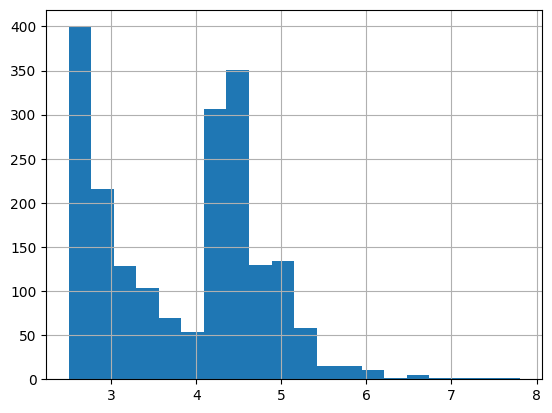

In [28]:
df['mag'].hist(bins=20)

this cmd makes a histogram with the specified number of bins dividing data into 20 bin


Peak at 3.0-4.0	            Most earthquakes are small magnitude
Sharp decline	Larger earthquakes are much rarer


Long tail to 8.0	         Some very large earthquakes exist


Total area under curve	   Total number of earthquakes in dataset


Right-skewed shape	        Distribution is not symmetric (typical for magnitudes)



In [29]:
df.groupby('status').mean(numeric_only=True)

,latitude,longitude,depth,mag,nst,gap,dmin,rms,horizontalError,depthError,magError,magNst
status,,,,,,,,,,,,
automatic,50.829952,-143.124676,26.807391,2.780000,64.114286,100.971429,0.335474,0.637429,2.825143,3.742292,0.273989,19.228571
reviewed,25.521002,-15.290699,56.533578,3.839478,45.585838,136.707590,2.336781,0.662590,8.177741,4.965092,0.118727,44.917305


groups all the numerical column's mean by the status column

In [30]:
df['locationSource'].value_counts(normalize=True)

,proportion
locationSource,
us,0.641642
ak,0.199700
pr,0.066066
nc,0.028529
hv,0.019520
tx,0.015015
ci,0.013013
nn,0.008008
uu,0.003504


shows the percentageof each value in the feature that how much the times ( in percentage ) this value was observed

In [31]:
df.select_dtypes(include='object')

,time,magType,net,id,updated,place,type,status,locationSource,magSource
0,2026-07-01T08:00:50.534Z,mb,us,us6000t9d9,2026-07-01T08:49:52.040Z,"83 km NNE of Ollagüe, Chile",earthquake,reviewed,us,us
1,2026-07-01T06:39:49.260Z,md,hv,hv74994382,2026-07-01T08:48:07.235Z,"5 km SE of Pāhala, Hawaii",earthquake,automatic,hv,hv
2,2026-07-01T06:23:39.283Z,mb,us,us6000t9cu,2026-07-01T06:49:17.040Z,southeast of the Loyalty Islands,earthquake,reviewed,us,us
3,2026-07-01T05:56:41.300Z,ml,ci,ci41284551,2026-07-01T06:07:17.020Z,"5 km W of Delta, B.C., MX",earthquake,automatic,ci,ci
4,2026-07-01T05:06:40.700Z,ml,hv,hv74994352,2026-07-01T07:24:40.324Z,"1 km W of Pāhala, Hawaii",earthquake,reviewed,hv,hv
...,...,...,...,...,...,...,...,...,...,...
1993,2026-06-01T01:24:38.944Z,ml,us,us7000sprh,2026-06-19T23:13:03.040Z,"154 km ESE of McCarthy, Alaska",earthquake,reviewed,us,us
1994,2026-06-01T00:36:36.507Z,mb,us,us7000sqy1,2026-06-25T03:19:10.040Z,"136 km NW of Ternate, Indonesia",earthquake,reviewed,us,us
1995,2026-06-01T00:33:28.750Z,md,pr,pr71518453,2026-06-01T02:48:31.040Z,"63 km N of Charlotte Amalie, U.S. Virgin Islands",earthquake,reviewed,pr,pr
1996,2026-06-01T00:25:16.746Z,ml,ak,aka2026ksydrc,2026-06-30T22:48:24.040Z,"16 km E of Pedro Bay, Alaska",earthquake,reviewed,ak,ak


printed all the columns with object data type

In [33]:
df['id'].str.contains('hv').sum()

np.int64(42)

the id column convert it into a string then search for 'hv' and sum the total number of times it occured

In [34]:
df.sort_values('mag',
ascending=False).head(5)

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
1556,2026-06-07T23:37:41.981Z,5.6171,125.0472,57.226,7.8,mww,151,21,1.537,0.53,...,2026-06-28T12:00:57.501Z,"24 km SW of Kablalan, Philippines",earthquake,8.99,4.718,0.028,125.0,reviewed,us,us
305,2026-06-24T22:05:11.566Z,10.4351,-68.4716,10.000,7.5,mww,97,50,9.681,0.61,...,2026-07-01T06:31:14.295Z,"28 km SE of Yumare, Venezuela",earthquake,9.24,1.804,0.036,75.0,reviewed,us,us
306,2026-06-24T22:04:33.389Z,10.4360,-68.5277,20.294,7.2,mww,100,21,2.587,0.60,...,2026-06-30T18:50:44.269Z,"23 km SE of Yumare, Venezuela",earthquake,9.64,3.917,0.073,18.0,reviewed,us,us
302,2026-06-24T22:30:14.931Z,40.2912,142.0981,50.923,6.9,mww,110,34,0.932,0.64,...,2026-06-26T17:59:56.650Z,"30 km ENE of Kuji, Japan",earthquake,5.80,4.369,0.053,34.0,reviewed,us,us
884,2026-06-16T03:27:44.418Z,-1.1173,120.1990,10.000,6.7,mww,120,33,3.896,1.26,...,2026-06-24T03:20:26.714Z,"43 km ESE of Palu, Indonesia",earthquake,8.95,1.713,0.041,56.0,reviewed,us,us


sorted the dataset with respeect to magnitude values in descending order from 8 - 3

In [35]:
df[df['mag'] > 5]

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
12,2026-06-30T23:44:54.830Z,37.8295,95.3273,10.000,5.3,mww,81,35,6.961,0.49,...,2026-07-01T02:41:27.215Z,"265 km SSE of Dunhuang, China",earthquake,9.92,1.788,0.075,17.0,reviewed,us,us
18,2026-06-30T21:01:34.191Z,24.6598,-109.0169,10.000,5.3,mww,53,135,3.778,0.72,...,2026-07-01T00:58:36.727Z,"95 km SSW of El Progreso, Mexico",earthquake,8.71,1.908,0.066,22.0,reviewed,us,us
20,2026-06-30T19:45:40.116Z,24.8239,-108.9285,10.000,6.0,mww,88,177,3.616,1.11,...,2026-07-01T00:18:50.818Z,"75 km SSW of El Progreso, Mexico",earthquake,9.09,1.893,0.038,68.0,reviewed,us,us
28,2026-06-30T14:41:10.582Z,-5.7270,150.9338,35.000,5.4,mww,76,50,1.957,1.16,...,2026-06-30T19:10:16.040Z,"90 km ESE of Kimbe, Papua New Guinea",earthquake,9.01,1.892,0.063,24.0,reviewed,us,us
53,2026-06-30T00:15:12.439Z,-55.5087,-27.2192,35.000,5.1,mb,74,57,5.488,0.83,...,2026-06-30T00:46:07.040Z,South Sandwich Islands region,earthquake,10.88,1.848,0.075,58.0,reviewed,us,us
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1870,2026-06-03T06:58:56.787Z,38.8332,72.1647,10.000,5.1,mb,68,42,0.577,1.17,...,2026-06-14T12:30:10.040Z,"71 km SE of Karakenja, Tajikistan",earthquake,4.77,1.558,0.049,136.0,reviewed,us,us
1933,2026-06-01T23:01:16.792Z,-2.0683,138.8508,27.275,5.4,mb,101,19,1.903,0.65,...,2026-06-08T03:20:41.573Z,"206 km WNW of Abepura, Indonesia",earthquake,7.18,3.839,0.046,162.0,reviewed,us,us
1940,2026-06-01T22:12:36.092Z,39.2548,15.7869,243.000,6.2,mww,132,24,0.738,0.78,...,2026-06-08T02:59:34.169Z,"23 km WSW of San Lucido, Italy",earthquake,6.49,1.838,0.028,124.0,reviewed,us,us
1988,2026-06-01T03:40:11.362Z,-35.3053,-104.5430,10.000,5.3,mww,83,68,9.124,0.58,...,2026-06-24T01:39:32.040Z,southeast of Easter Island,earthquake,12.36,1.835,0.083,14.0,reviewed,us,us


fitler the dataset with magnitude values > 5

In [39]:
pd.pivot_table(df, values='mag', index='net' ,aggfunc='mean')

,mag
net,
ak,2.861153
av,2.783333
ci,2.974827
hv,3.020513
nc,2.979474
nm,3.220000
nn,2.932500
ok,2.640000
pr,3.287955


Average earthquake magnitude recorded by each network.

In [40]:
df.memory_usage()

,0
Index,132
time,15984
latitude,15984
longitude,15984
depth,15984
mag,15984
magType,15984
nst,15984
gap,15984
dmin,15984


This shows how much memory (in bytes) each column in your DataFrame is using.

In [43]:
df['mag'].mode()

,mag
0,4.4


the most occuring values - mode

In [50]:
df.cov(numeric_only=True)

,latitude,longitude,depth,mag,nst,gap,dmin,rms,horizontalError,depthError,magError,magNst
latitude,818.765600,-1138.385055,-945.651816,-16.059529,89.382162,459.170493,-41.877601,-0.633653,-23.833272,-10.961928,0.308518,-24.439327
longitude,-1138.385055,18024.511322,463.637152,74.974201,19.963319,-1655.573332,123.365222,8.289713,260.538959,9.919660,-1.787207,295.465391
depth,-945.651816,463.637152,9242.808513,18.010776,284.973338,-1034.965135,28.839096,3.583460,120.315748,121.462885,-0.488460,831.097085
mag,-16.059529,74.974201,18.010776,0.871225,11.063051,-27.112834,1.422494,0.099396,1.288634,-0.033118,-0.026210,15.566539
nst,89.382162,19.963319,284.973338,11.063051,1475.353512,-1511.041260,2.141495,2.072786,-51.448765,-26.043423,-0.398888,1135.542888
gap,459.170493,-1655.573332,-1034.965135,-27.112834,-1511.041260,5633.000352,-38.184711,-5.790636,101.301856,104.033899,0.683338,-1514.445736
dmin,-41.877601,123.365222,28.839096,1.422494,2.141495,-38.184711,14.474394,0.138873,6.454646,-0.942157,-0.042289,15.845123
rms,-0.633653,8.289713,3.583460,0.099396,2.072786,-5.790636,0.138873,0.093185,0.339109,-0.066699,-0.004112,2.322498
horizontalError,-23.833272,260.538959,120.315748,1.288634,-51.448765,101.301856,6.454646,0.339109,41.222429,6.928422,-0.006875,-28.359018
depthError,-10.961928,9.919660,121.462885,-0.033118,-26.043423,104.033899,-0.942157,-0.066699,6.928422,24.794604,0.000410,-28.005188


covarience of the numeric only columns

In [52]:
df.kurt(numeric_only=True)

,0
latitude,-0.433860
longitude,-1.687922
depth,15.702429
mag,-0.755141
nst,6.657785
gap,-0.568150
dmin,36.130422
rms,0.105191
horizontalError,26.142138
depthError,9.757294


shows kurtosis of the numeric only columns

In [54]:
df.skew(numeric_only = True)

,0
latitude,-0.616294
longitude,0.210294
depth,3.769582
mag,0.157868
nst,2.213873
gap,0.502194
dmin,5.152851
rms,0.225051
horizontalError,3.332664
depthError,2.606687


shows the skewness of the numeric columns

# **SECTION #04** *key findings*

the depth values are right skewed Most values are small, but there are some very large values.

the depth has high kurtosis values  meaning it has alot if outliers- heavy tail

Most earthquakes are small magnitude and Larger earthquakes are much rarer